# **Driver Drowsiness and Distraction Detection Using Deep Learning with Multi Class Behavioural Analysis**

## Define the Problem
* Develop a Deep Learning Model **to automatically detect Driver Drowsiness and Distraction from visual data**.
* Perform Multi-class classification of driver behaviors;
  * Normal Driving
  * Yawning
  * Talking
  * Eye Closed
* Help **to reduce accidents by detecting unsafe driving behavior early**

## Goal
* **Classify the driver behavior** into different catagories based on images.
* **Detect important actions** like Yawning, talking, eye closure, and lack of attention.
* **Ensure the system works well under different conditions like lighting and camera angles**.
* **Reduce the mistakes**, especially when the driver is actually tired but predicted as normal.

## Expected Outcome
* A system that can recognise different driver behaviors correctly and accurately.
* Better identification of drowsiness and distraction compared to basic methods.
* Clear results showing how well the system performs.

## Collect Data
* All the data are collected from Kaggle.
* Dataset : https://www.kaggle.com/datasets/samymesbah/nthu-dataset-ddd-multi-class
* This dataset contains:
  * Images of **drivers showing different behaviors while driving**.
  * Multiple categories such as **normal driving, yawning, talking, eye closed and other distraction actions.**
  * Data collected under different conditions like **lighting, with glasses, and various head positions**.
  * Frames **extracted from videos, organised into folders** based on driver behavior.

## Import Libraries

In [1]:
# Data Handling
import numpy as np
import os
import shutil, zipfile
from google.colab import drive
import random

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
import tensorflow as tf
import cv2

# Model Bulding
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix

## Import Dataset

In [2]:
# Mount Google Drive
drive.mount("/content/drive")

# Import file from Google Drive
zip_src = "/content/drive/MyDrive/Studies/Entri/nthu-dataset-ddd-multi-class.zip"
zip_dst = "/content/nthu-dataset-ddd-multi-class.zip"

if not os.path.exists(zip_dst):
    print("Copying zip from Drive... please wait")
    shutil.copy(zip_src, zip_dst)
    print("Copy done")
else:
    print("Zip already copied, skipping")

# Unzip the Dataset
if not os.path.exists('Multi class'):
    print("Unzipping... please wait (2-3 minutes)")
    with zipfile.ZipFile(zip_dst, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("Unzipped successfully")
else:
    print("Already unzipped, skipping")

Mounted at /content/drive
Copying zip from Drive... please wait
Copy done
Unzipping... please wait (2-3 minutes)
Unzipped successfully


### Re-order the Folders

In [3]:
files = 'train'

# Move folders up and rename
for old, new in [('yawning','yawning'), ('slowBlinkWithNodding','slowblink'), ('sleepyCombination','sleepy')]:
    src, dst = f'{files}/drowsy/{old}', f'{files}/{new}'
    if os.path.exists(src):
        shutil.move(src, dst)

# Delete empty drowsy/
if os.path.exists(f'{files}/drowsy'):
    shutil.rmtree(f'{files}/drowsy')

# Verify
for folder in sorted(os.listdir(files)):
    count = len(os.listdir(f'{files}/{folder}'))
    print(f"- {folder} : {count:,} images")

- notdrowsy : 30,491 images
- sleepy : 17,756 images
- slowblink : 9,412 images
- yawning : 8,862 images


## Create a Test Split

In [4]:
base = 'train'
test_base = 'test'
os.makedirs(test_base, exist_ok=True)

# Move 10% from each class to test folder
for cls in sorted(os.listdir(base)):
    src_folder = f'{base}/{cls}'
    dst_folder = f'{test_base}/{cls}'
    os.makedirs(dst_folder, exist_ok=True)

    all_images = os.listdir(src_folder)
    test_size = int(len(all_images) * 0.10)
    test_images = random.sample(all_images, test_size)

    for img in test_images:
        shutil.move(f'{src_folder}/{img}',
                    f'{dst_folder}/{img}')

# Verify
print("Test folder:")
for cls in sorted(os.listdir(test_base)):
    count = len(os.listdir(f'{test_base}/{cls}'))
    print(f"  - {cls}: {count:,} images")

print("\nRemaining Train folder:")
for cls in sorted(os.listdir(base)):
    count = len(os.listdir(f'{base}/{cls}'))
    print(f"  - {cls}: {count:,} images")

Test folder:
  - notdrowsy: 3,049 images
  - sleepy: 1,775 images
  - slowblink: 941 images
  - yawning: 886 images

Remaining Train folder:
  - notdrowsy: 27,442 images
  - sleepy: 15,981 images
  - slowblink: 8,471 images
  - yawning: 7,976 images


### Observations:
* The original dataset was organized as a binary classification problem with two main folders: drowsy and notdrowsy.
* Inside the drowsy folder, there were multiple subfolders representing different drowsiness conditions.
* To convert the dataset into a multi class classification problem, the subfolders inside drowsy were separated and treated as individual classes.
* The dataset was reorganized into four final classes: notdrowsy, sleepy, slowblink, and yawning.
* The main drowsy folder was removed after restructuring the dataset.
* The verification output confirms that the folders were successfully renamed and reorganized.
* The dataset is still imbalanced because notdrowsy contains significantly more images than the other classes.
* This class imbalance may affect model training and prediction performance.

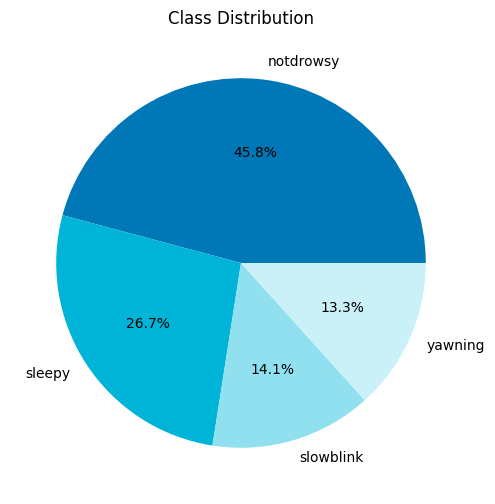

In [5]:
classes = ['notdrowsy', 'sleepy', 'slowblink', 'yawning']
counts = [30491, 17756, 9412, 8862]

# Class Distribution Chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=classes, autopct='%1.1f%%',
        colors=['#0077b6', '#00b4d8', '#90e0ef', '#caf0f8'])
plt.title('Class Distribution')
plt.show()

## Sample Images

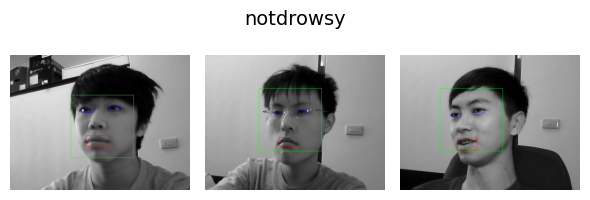

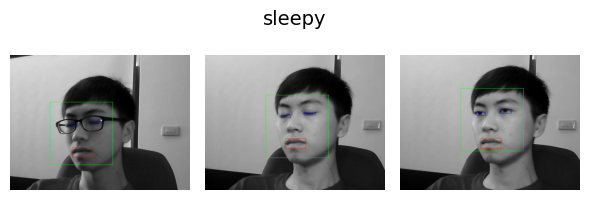

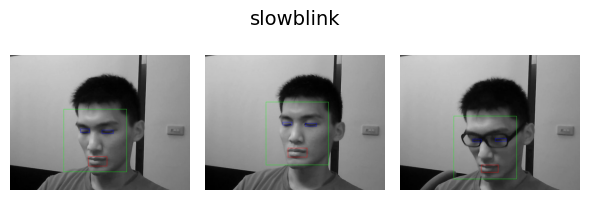

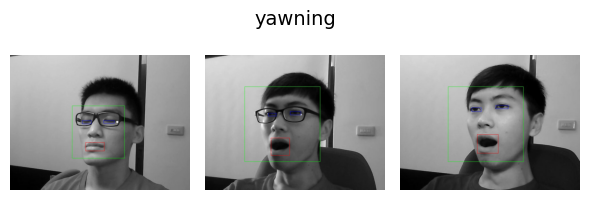

In [6]:
# Display Random Sample Images
base = 'train'

for cls in sorted(os.listdir(base)):
    images = random.sample(os.listdir(f'{base}/{cls}'), 3)
    fig, axes = plt.subplots(1, 3, figsize=(6, 2))
    fig.suptitle(cls.lower(), fontsize=14)
    for ax, img_name in zip(axes, images):
        img = cv2.imread(f'{base}/{cls}/{img_name}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Preprocess the Data

In [8]:
# Image Resizing
IMG_SIZE = 96

def preprocess_image(img_path):
  img = cv2.imread(img_path)

  if img is None:
    return None

  img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
  img = img.astype("float32")/255.0

  return img

# Model Framework and Architecture
* The dataset consists of images of driver behaior, **CNN (Convolutional Neural Networks)** are used **to extract the important visual features such as eyes, mouth, and facial expressions**.

## Train Validation Split

In [9]:
# Training generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

# Validation generator
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Test generator
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "train",
    target_size=(96, 96),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "train",
    target_size=(96, 96),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# VERIFY
print("\nClasses found:", train_generator.class_indices)
print("Number of classes:", train_generator.num_classes)
x_batch, y_batch = next(iter(train_generator))
print("Label shape (must be (32, 4)):", y_batch.shape)

Found 47897 images belonging to 4 classes.
Found 11973 images belonging to 4 classes.
Found 6651 images belonging to 4 classes.

Classes found: {'notdrowsy': 0, 'sleepy': 1, 'slowblink': 2, 'yawning': 3}
Number of classes: 4
Label shape (must be (32, 4)): (32, 4)


## Import Pre-Trained Model
### MobileNetV2

* **MobileNetV2** is a lightweight and efficient model used for image classification tasks.
* It provides good accuracy while using less memory and processing power compared to larger models.
* The pre-trained MobileNetV2 model is already trained on large datasets such as ImageNet.
* It can recognize general image features like edges, shapes, and patterns.
* In this project, transfer learning was used by fine-tuning MobileNetV2 on the custom drowsiness dataset.
* The model was trained for multi class classification with four classes.
* Using a pre-trained model helped reduce training time and improve performance, especially with limited data.


In [10]:
# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze base model
base_model.trainable = False

# Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
output = Dense(4, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Model Compile

In [11]:
# Model Compile
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Model Training

In [12]:
from sklearn.utils.class_weight import compute_class_weight

In [13]:
# Class weights
classes_array = np.unique(train_generator.classes)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes_array,
    y=train_generator.classes
)
class_weights = dict(zip(classes_array, weights))
print("Class weights:", class_weights)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True),
    ModelCheckpoint(
        '/content/drive/MyDrive/Studies/Entri/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6)
]

Class weights: {np.int32(0): np.float64(0.5454245240047372), np.int32(1): np.float64(0.9365858427845131), np.int32(2): np.float64(1.7668953814372141), np.int32(3): np.float64(1.8765475630778874)}


In [14]:
# Train the Model
model_train = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 653s 431ms/step - accuracy: 0.6581 - loss: 0.7681 - val_accuracy: 0.2797 - val_loss: 1.5521 - learning_rate: 0.0010
Epoch 2/15
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 593s 396ms/step - accuracy: 0.7491 - loss: 0.5593 - val_accuracy: 0.3402 - val_loss: 1.4268 - learning_rate: 0.0010
Epoch 3/15
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 618s 394ms/step - accuracy: 0.7715 - loss: 0.4990 - val_accuracy: 0.2835 - val_loss: 1.8727 - learning_rate: 0.0010
Epoch 4/15
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 587s 392ms/step - accuracy: 0.7851 - loss: 0.4649 - val_accuracy: 0.3116 - val_loss: 1.7120 - learning_rate: 0.0010
Epoch 5/15
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 592s 395ms/step - accuracy: 0.7937 - loss: 0.4451 - val_accuracy: 0.3481 - val_loss: 1.6710 - learning_rate: 0.0010
Epoch 6/15
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 594s 397ms/step - accuracy: 0.8080 - loss: 0.4087 - val_accuracy: 0.3447 - val_loss: 1.8838 - learning_rate: 5.0000e-04
Epoch 7/15
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 585s 3

## Model Evaluation

In [16]:
# Test Evaluation
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Test Accuracy
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy (Before Fine-tuning): {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

208/208 ━━━━━━━━━━━━━━━━━━━━ 57s 265ms/step
Test Accuracy (Before Fine-tuning): 75.58%
Test Loss: 0.6129


## Classification Report

In [17]:
# Classification Report
print("Classification Report (Before Fine-tuning):")
print(classification_report(
    y_true, y_pred,
    target_names=class_names)
)

Classification Report (Before Fine-tuning):
              precision    recall  f1-score   support

   notdrowsy       0.83      0.72      0.77      3049
      sleepy       0.79      0.78      0.78      1775
   slowblink       0.63      0.80      0.70       941
     yawning       0.66      0.78      0.71       886

    accuracy                           0.76      6651
   macro avg       0.73      0.77      0.74      6651
weighted avg       0.77      0.76      0.76      6651



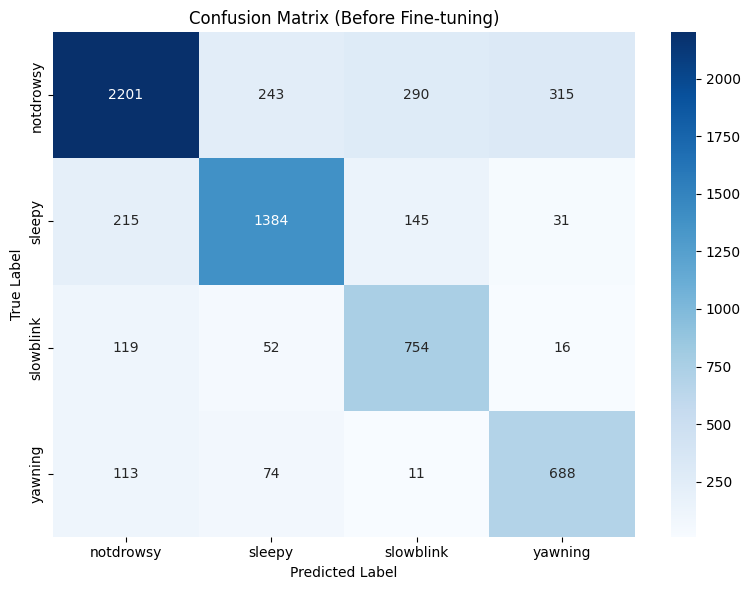

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix (Before Fine-tuning)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Parameter Tuning

In [19]:
# Unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with very low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune callbacks
callbacks_ft = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True),
    ModelCheckpoint(
        '/content/drive/MyDrive/Studies/Entri/best_model_finetuned.keras',
        monitor='val_accuracy',
        save_best_only=True)
]

## Model Training - Tuning

In [20]:
# Train
model_train_ft = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_ft
)

Epoch 1/10
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 821s 541ms/step - accuracy: 0.6537 - loss: 2.1253 - val_accuracy: 0.3926 - val_loss: 2.3777
Epoch 2/10
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 799s 534ms/step - accuracy: 0.7289 - loss: 0.6546 - val_accuracy: 0.3553 - val_loss: 2.1769
Epoch 3/10
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 814s 544ms/step - accuracy: 0.7714 - loss: 0.5075 - val_accuracy: 0.3850 - val_loss: 2.2003
Epoch 4/10
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 809s 540ms/step - accuracy: 0.8046 - loss: 0.4155 - val_accuracy: 0.3839 - val_loss: 2.2576
Epoch 5/10
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 821s 548ms/step - accuracy: 0.8297 - loss: 0.3584 - val_accuracy: 0.4240 - val_loss: 2.2890
Epoch 6/10
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 812s 542ms/step - accuracy: 0.8464 - loss: 0.3178 - val_accuracy: 0.4566 - val_loss: 2.4842
Epoch 7/10
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 787s 525ms/step - accuracy: 0.8596 - loss: 0.2836 - val_accuracy: 0.4591 - val_loss: 2.6052
Epoch 8/10
1497/1497 ━━━━━━━━━━━━━━━━━━━━ 833s 546ms/step - ac

## Accuracy vs Loss Curve

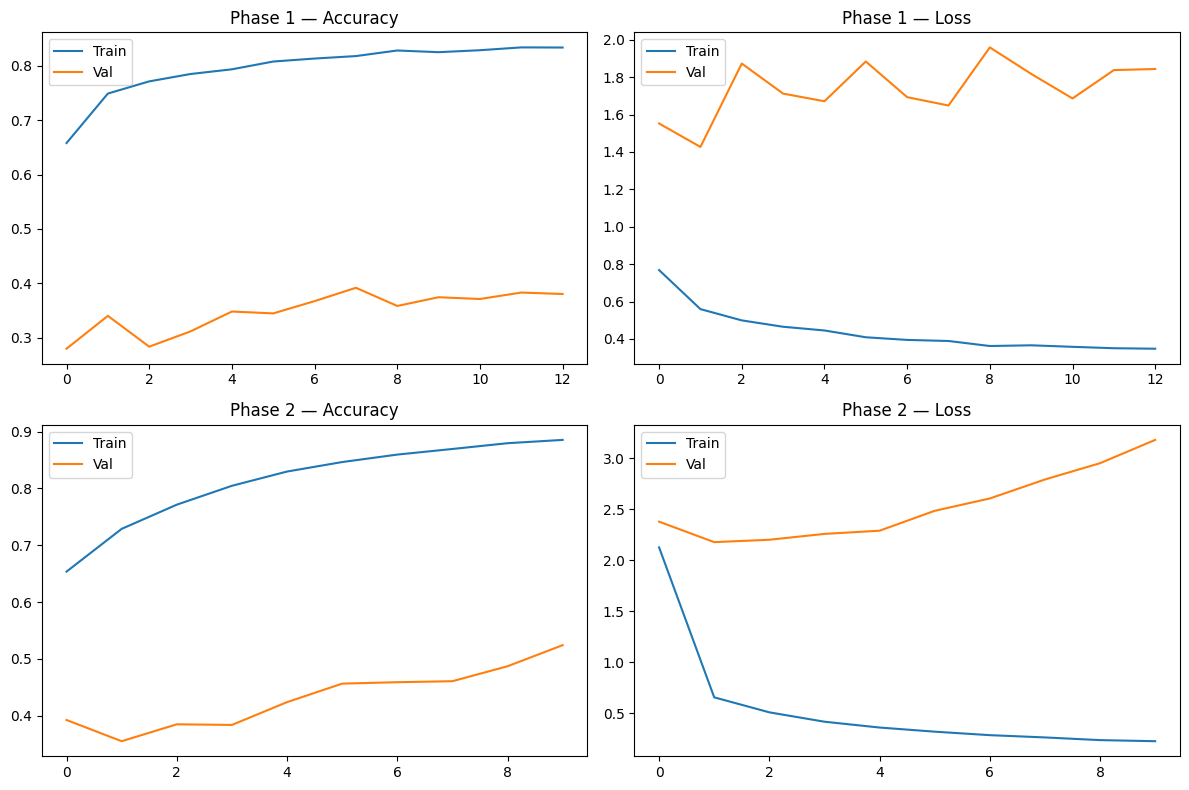

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Phase 1
axes[0, 0].plot(model_train.history['accuracy'], label='Train')
axes[0, 0].plot(model_train.history['val_accuracy'], label='Val')
axes[0, 0].set_title('Phase 1 — Accuracy')
axes[0, 0].legend()

axes[0, 1].plot(model_train.history['loss'], label='Train')
axes[0, 1].plot(model_train.history['val_loss'], label='Val')
axes[0, 1].set_title('Phase 1 — Loss')
axes[0, 1].legend()

# Phase 2
axes[1, 0].plot(model_train_ft.history['accuracy'], label='Train')
axes[1, 0].plot(model_train_ft.history['val_accuracy'], label='Val')
axes[1, 0].set_title('Phase 2 — Accuracy')
axes[1, 0].legend()

axes[1, 1].plot(model_train_ft.history['loss'], label='Train')
axes[1, 1].plot(model_train_ft.history['val_loss'], label='Val')
axes[1, 1].set_title('Phase 2 — Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Model Evaluation - Tuning

In [22]:
# Test Set Evaluation — After Fine-tuning
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Test Accuracy
test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Test Accuracy (After Fine-tuning): {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print("\nClassification Report (After Fine-tuning):")
print(classification_report(y_true, y_pred,
                             target_names=class_names))

208/208 ━━━━━━━━━━━━━━━━━━━━ 54s 253ms/step
Test Accuracy (After Fine-tuning): 82.90%
Test Loss: 0.7818

Classification Report (After Fine-tuning):
              precision    recall  f1-score   support

   notdrowsy       0.85      0.82      0.84      3049
      sleepy       0.93      0.81      0.86      1775
   slowblink       0.71      0.84      0.77       941
     yawning       0.75      0.88      0.81       886

    accuracy                           0.83      6651
   macro avg       0.81      0.84      0.82      6651
weighted avg       0.84      0.83      0.83      6651



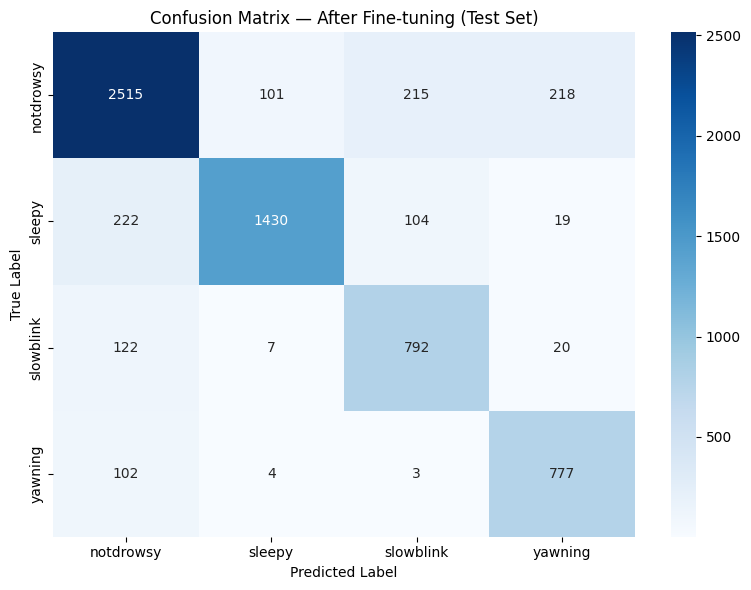

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — After Fine-tuning (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Save Model

In [24]:
# Save Model to Google Drive
model.save('/content/drive/MyDrive/Studies/Entri/driver_drowsiness_model.h5')
print("Model saved successfully!")

# Verify
import os
size = os.path.getsize('/content/drive/MyDrive/Studies/Entri/driver_drowsiness_model.h5')
print(f"Model size: {size/1024/1024:.1f} MB")

Model saved successfully!
Model size: 22.7 MB
